## Chapter 3: Composition Creates Complexity

In [ ]:
## 3.1  Composition of functions
#Step 1: Define Functions# Define f(x) = x^2
def f(x):
    return x * x

# Define g(x) = 2x + 1
def g(x):
    return 2*x + 1

# Define composition f(g(x))
def fog(x):
    return f(g(x))

In [ ]:
# Generate values from -5 to 5
x_values = []
start = -5
end = 5
step = 0.1

x = start
while x <= end:
    x_values.append(x)
    x += step

In [ ]:
f_values = []
g_values = []
fog_values = []

for x in x_values:
    f_values.append(f(x))
    g_values.append(g(x))
    fog_values.append(fog(x))

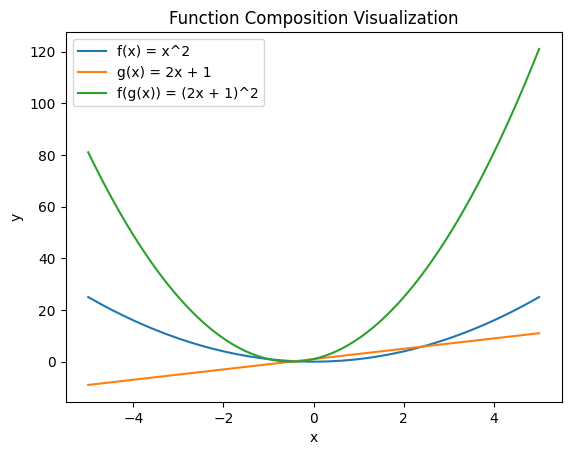

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(x_values, f_values, label="f(x) = x^2")
plt.plot(x_values, g_values, label="g(x) = 2x + 1")
plt.plot(x_values, fog_values, label="f(g(x)) = (2x + 1)^2")

plt.title("Function Composition Visualization")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()




```
# This is formatted as code
```

### Why linearity fails

/tmp/ipykernel_2511/3606919281.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')


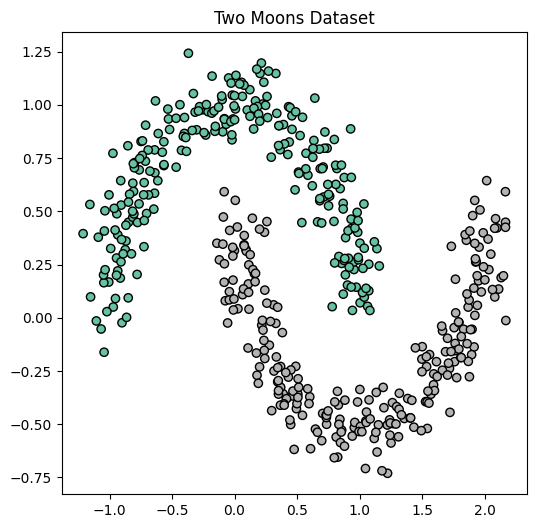

/tmp/ipykernel_2511/3606919281.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')
/tmp/ipykernel_2511/3606919281.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))


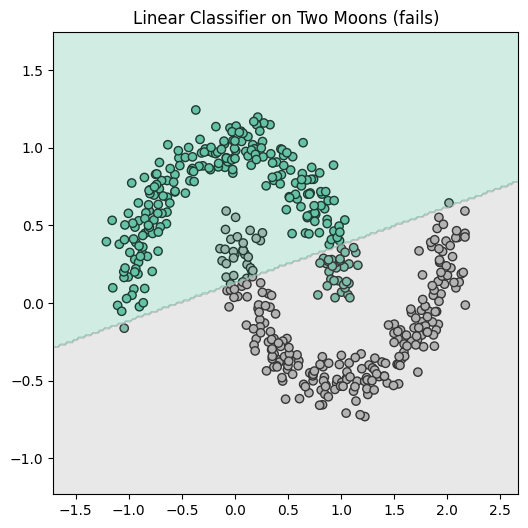

/tmp/ipykernel_2511/3606919281.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))
/tmp/ipykernel_2511/3606919281.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')


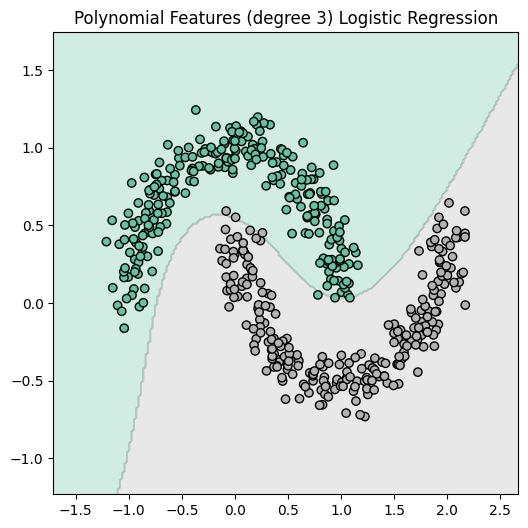

/tmp/ipykernel_2511/3606919281.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))
/tmp/ipykernel_2511/3606919281.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')


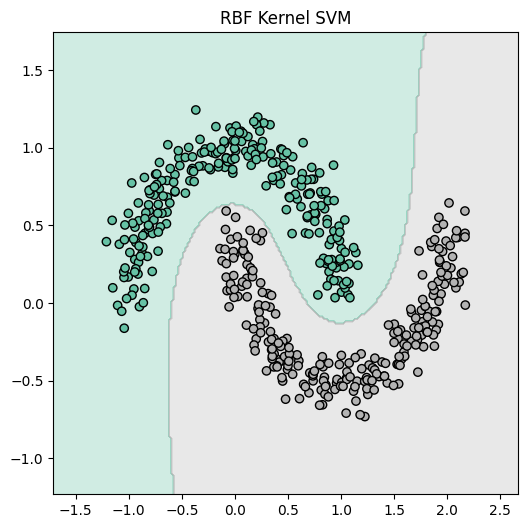

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

# Generate Two Moons dataset
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)

# Define custom colors
colors = ['#2ca02c', '#ff7f0e']  # green and orange

# Visualize original data
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')
plt.title("Two Moons Dataset")
plt.show()

# Linear classifier (fails)
linear_clf = LogisticRegression()
linear_clf.fit(X, y)
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = linear_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))
plt.title("Linear Classifier on Two Moons (fails)")
plt.show()

# Nonlinear transformation using polynomial features
poly_clf = make_pipeline(PolynomialFeatures(degree=3), LogisticRegression())
poly_clf.fit(X, y)
Z = poly_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')
plt.title("Polynomial Features (degree 3) Logistic Regression")
plt.show()

# Another nonlinear method: Kernel SVM
svm_clf = SVC(kernel='rbf', gamma=1.0)
svm_clf.fit(X, y)
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Set2', 2))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.get_cmap('Set2', 2), edgecolors='k')
plt.title("RBF Kernel SVM")
plt.show()


Generates the two interleaved moons.

Shows that a linear classifier can’t separate them.

Applies a polynomial feature transformation (folding the space) to make the data linearly separable in higher dimensions.

Shows a nonlinear kernel SVM as another effective method

### Activation functions


Sigmoid

Formula:
𝜎
(
𝑥
)
=
1
1
+
𝑒
−
𝑥
σ(x)=
1+e
−x
1
	​


Range: (0, 1)

Use Case: Output layer for binary classification.

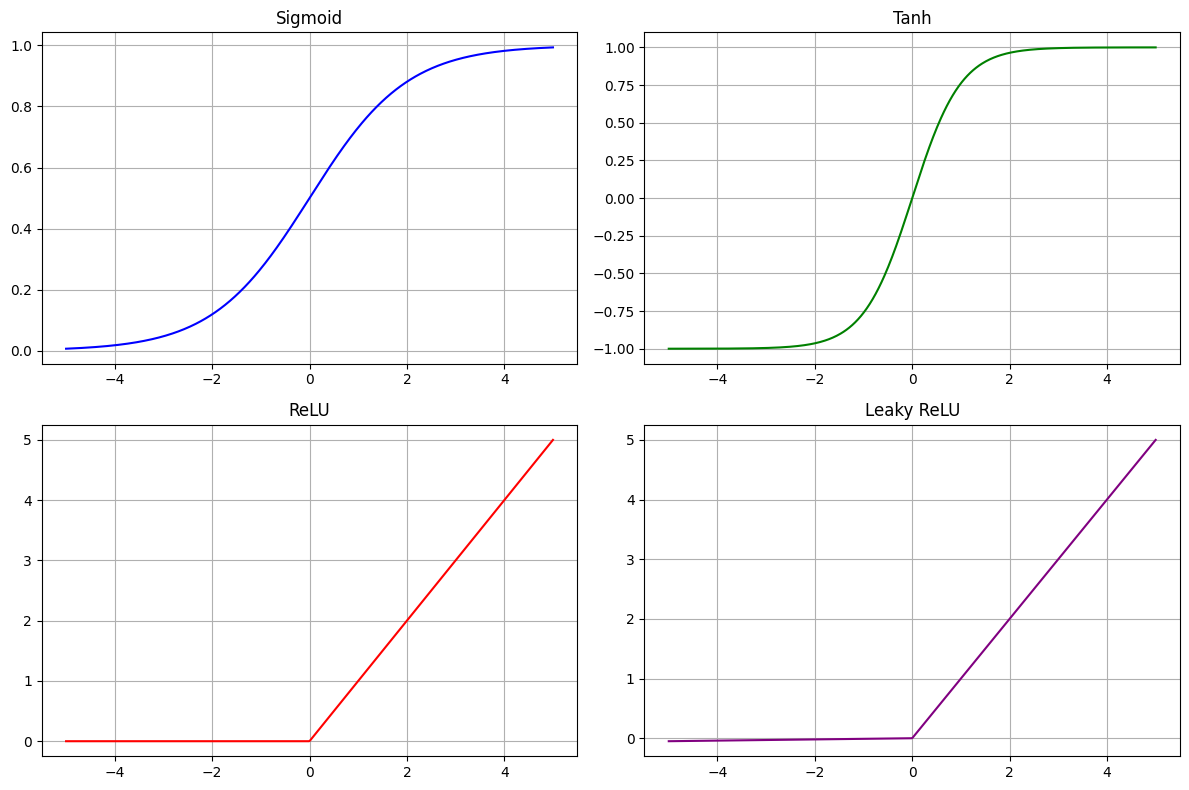

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define x values
x = np.linspace(-5, 5, 500)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)


# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid', color='blue')
plt.title('Sigmoid')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(x, tanh(x), label='Tanh', color='green')
plt.title('Tanh')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(x, relu(x), label='ReLU', color='red')
plt.title('ReLU')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(x, leaky_relu(x), label='Leaky ReLU', color='purple')
plt.title('Leaky ReLU')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot Softmax separately (since it's multi-dimensional)
#x_softmax = np.array([1.0, 2.0, 3.0])
#y_softmax = softmax(x_softmax)

#plt.figure(figsize=(6, 4))
#plt.bar(range(len(x_softmax)), y_softmax, color='orange')
#plt.title('Softmax')
#plt.xlabel('Index')
#plt.ylabel('Probability')
#plt.show()



###Exercise 3.11. Implement a neural network with one hidden layer for Two Moons classification. Write forward pass, loss computation, and verify gradients numerically. Train the network and plot the loss curve.

W1 gradient difference: 4.460664407290871e-10
b1 gradient difference: 1.2254462527193366e-11
W2 gradient difference: 9.195277265311441e-11
b2 gradient difference: 3.1556601082227687e-10


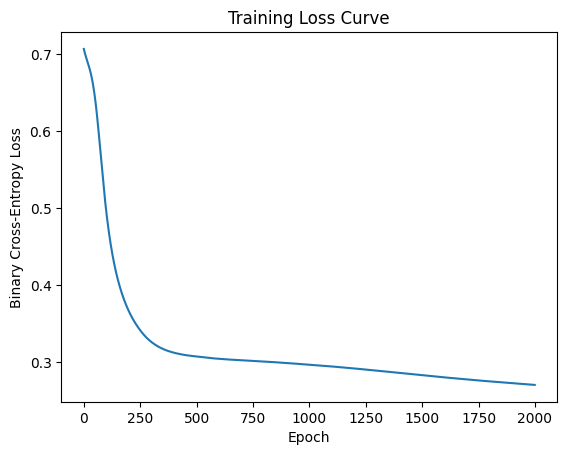

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# -----------------------
# 1️⃣ Generate Data
# -----------------------
X, y = make_moons(n_samples=300, noise=0.2, random_state=0)

scaler = StandardScaler()
X = scaler.fit_transform(X)

y = y.reshape(-1, 1)

# -----------------------
# 2️⃣ Initialize Parameters
# -----------------------
input_dim = 2
hidden_dim = 10
output_dim = 1

W1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros((1, output_dim))

# -----------------------
# 3️⃣ Activation Functions
# -----------------------
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

# -----------------------
# 4️⃣ Forward Pass
# -----------------------
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

# -----------------------
# 5️⃣ Loss (Binary Cross Entropy)
# -----------------------
def compute_loss(y, y_hat):
    m = y.shape[0]
    eps = 1e-8
    loss = -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))
    return loss


# -----------------------
# 6️⃣ Backward Pass
# -----------------------
def backward(X, y, W2, cache):
    Z1, A1, Z2, A2 = cache
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

# -----------------------
# 7️⃣ Numerical Gradient Check
# -----------------------
def gradient_check(X, y, W1, b1, W2, b2, epsilon=1e-5):

    def get_loss(W1, b1, W2, b2):
        y_hat, _ = forward(X, W1, b1, W2, b2)
        return compute_loss(y, y_hat)

    # Compute analytical gradients
    y_hat, cache = forward(X, W1, b1, W2, b2)
    dW1, db1, dW2, db2 = backward(X, y, W2, cache)

    # Check one random parameter from each matrix
    for param, dparam, name in [
        (W1, dW1, "W1"),
        (b1, db1, "b1"),
        (W2, dW2, "W2"),
        (b2, db2, "b2")
    ]:
        idx = tuple(np.random.randint(s) for s in param.shape)
        original = param[idx]

        param[idx] = original + epsilon
        loss_plus = get_loss(W1, b1, W2, b2)

        param[idx] = original - epsilon
        loss_minus = get_loss(W1, b1, W2, b2)

        param[idx] = original

        grad_numeric = (loss_plus - loss_minus) / (2 * epsilon)
        grad_analytic = dparam[idx]

        print(f"{name} gradient difference:",
              abs(grad_numeric - grad_analytic))

gradient_check(X, y, W1, b1, W2, b2)

# -----------------------
# 8️⃣ Training
# -----------------------
learning_rate = 0.1
epochs = 2000
losses = []

for epoch in range(epochs):
    # Forward
    y_hat, cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, y_hat)
    losses.append(loss)

    # Backward
    dW1, db1, dW2, db2 = backward(X, y, W2, cache)

    # Update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

# -----------------------
# 9️⃣ Plot Loss Curve
# -----------------------
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

Exercise 3.12. Explore the effect of hidden layer width on Two Moons. Train networks with m ∈ {1, 2, 4, 8, 16, 32, 64}. Visualize the decision boundary for several widths. Is there a point of diminishing returns?

Width 1 → Final loss: 0.2955
Width 2 → Final loss: 0.2895
Width 4 → Final loss: 0.1094
Width 8 → Final loss: 0.0947
Width 16 → Final loss: 0.0850
Width 32 → Final loss: 0.0751
Width 64 → Final loss: 0.0718


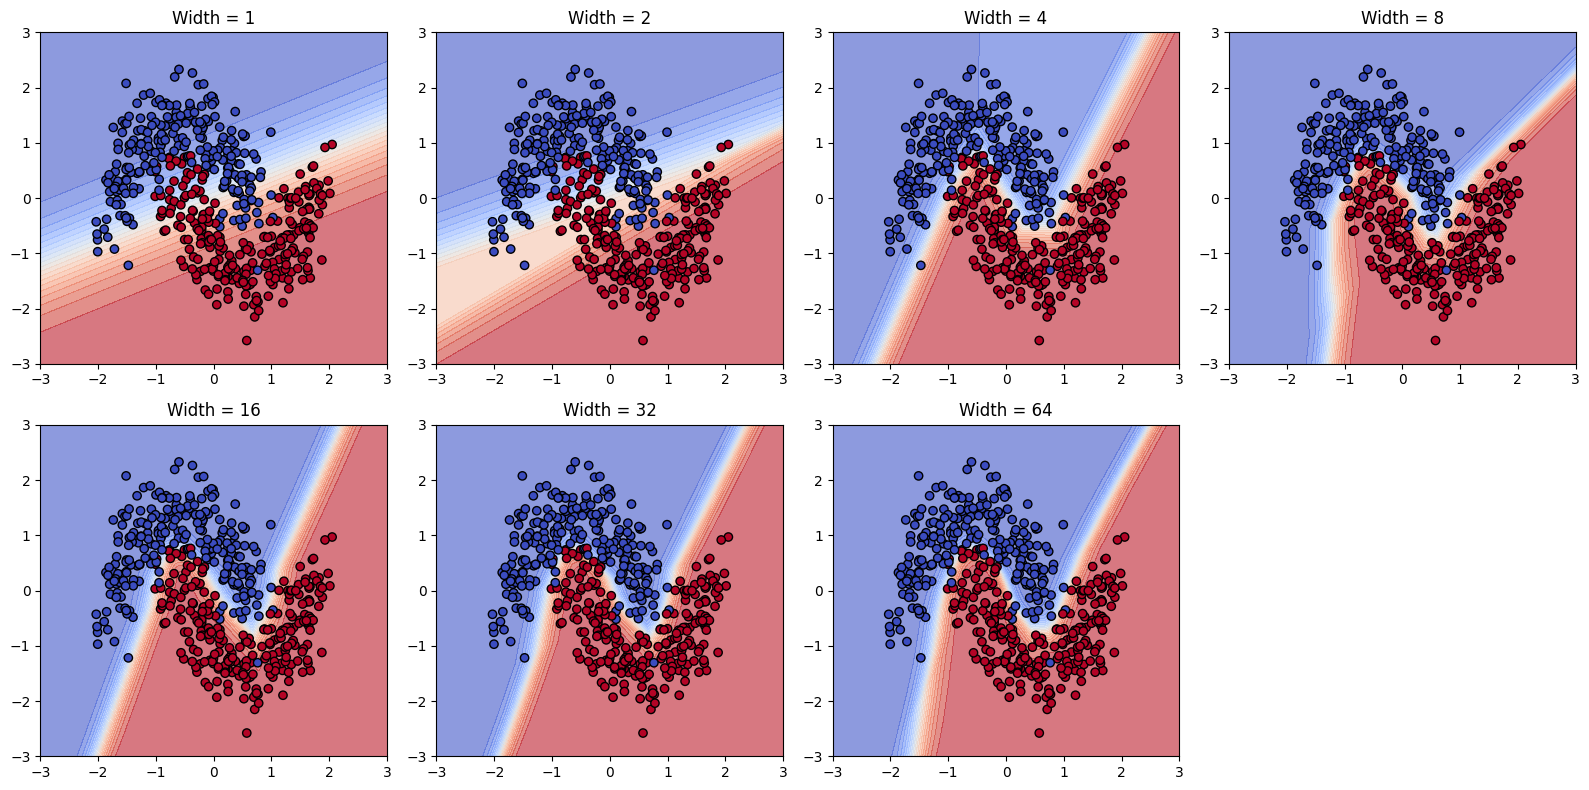

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# -----------------------
# Data
# -----------------------
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.reshape(-1, 1)

# -----------------------
# Activations
# -----------------------
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def compute_loss(y, y_hat):
    eps = 1e-8
    return -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))

# -----------------------
# Training Function
# -----------------------
def train_network(X, y, hidden_dim, epochs=3000, lr=0.1):

    n, d = X.shape

    W1 = np.random.randn(d, hidden_dim) * np.sqrt(2/d)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2/hidden_dim)
    b2 = np.zeros((1, 1))

    losses = []

    for _ in range(epochs):

        # Forward
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        loss = compute_loss(y, A2)
        losses.append(loss)

        # Backward
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2 / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_deriv(Z1)
        dW1 = X.T @ dZ1 / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, losses[-1]

# -----------------------
# Widths to Explore
# -----------------------
widths = [1, 2, 4, 8, 16, 32, 64]

results = {}
final_losses = []

for m in widths:
    W1, b1, W2, b2, final_loss = train_network(X, y, m)
    results[m] = (W1, b1, W2, b2)
    final_losses.append(final_loss)
    print(f"Width {m} → Final loss: {final_loss:.4f}")

# -----------------------
# Decision Boundary Plots
# -----------------------
xx, yy = np.meshgrid(np.linspace(-3, 3, 300),
                     np.linspace(-3, 3, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, m in enumerate(widths):
    W1, b1, W2, b2 = results[m]

    Z1 = grid @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    probs = sigmoid(Z2).reshape(xx.shape)

    axes[i].contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.6)
    axes[i].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", edgecolor="k")
    axes[i].set_title(f"Width = {m}")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

# -----------------------
# Loss vs Width Plot

Exercise 3.13. Investigate the role of activation functions. Implement sigmoid, tanh, and ReLU. Train three networks on Two Moons, identical except for activation function. Compare convergence speed and final decision boundaries.

Training with sigmoid activation...
Final loss (sigmoid): 0.2522

Training with tanh activation...
Final loss (tanh): 0.0988

Training with relu activation...
Final loss (relu): 0.0857



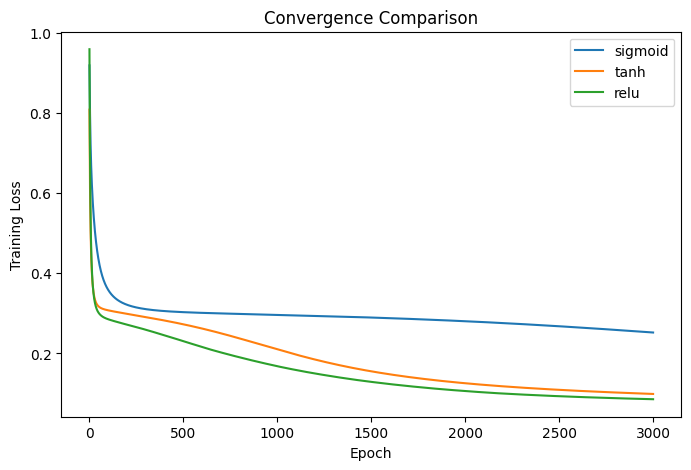

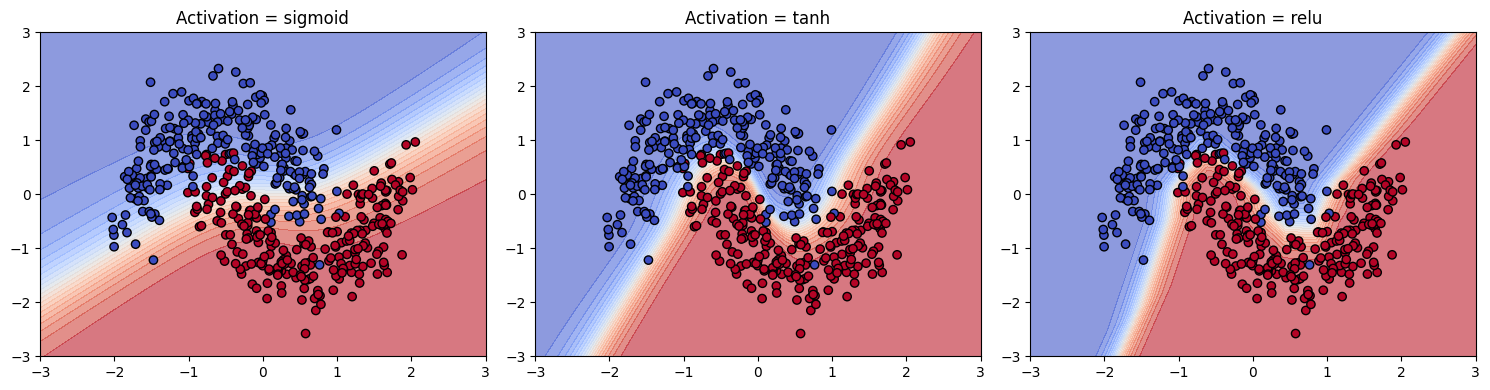

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# -----------------------
# Data
# -----------------------
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.reshape(-1, 1)

# -----------------------
# Activations
# -----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

def tanh(z):
    return np.tanh(z)

def tanh_deriv(a):
    return 1 - a**2

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

# -----------------------
# Loss
# -----------------------
def compute_loss(y, y_hat):
    eps = 1e-8
    return -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))

# -----------------------
# Training Function
# -----------------------
def train_network(X, y, activation="relu", hidden_dim=16,
                  epochs=3000, lr=0.1):

    n, d = X.shape

    # He/Xavier-like scaling
    W1 = np.random.randn(d, hidden_dim) * np.sqrt(2/d)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2/hidden_dim)
    b2 = np.zeros((1, 1))

    losses = []

    for _ in range(epochs):

        # Forward
        Z1 = X @ W1 + b1

        if activation == "relu":
            A1 = relu(Z1)
        elif activation == "tanh":
            A1 = tanh(Z1)
        elif activation == "sigmoid":
            A1 = sigmoid(Z1)

        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        loss = compute_loss(y, A2)
        losses.append(loss)

        # Backward
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2 / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        dA1 = dZ2 @ W2.T

        if activation == "relu":
            dZ1 = dA1 * relu_deriv(Z1)
        elif activation == "tanh":
            dZ1 = dA1 * tanh_deriv(A1)
        elif activation == "sigmoid":
            dZ1 = dA1 * sigmoid_deriv(A1)

        dW1 = X.T @ dZ1 / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, losses

# -----------------------
# Train Three Networks
# -----------------------
activations = ["sigmoid", "tanh", "relu"]
results = {}

for act in activations:
    print(f"Training with {act} activation...")
    W1, b1, W2, b2, losses = train_network(X, y, activation=act)
    results[act] = (W1, b1, W2, b2, losses)
    print(f"Final loss ({act}): {losses[-1]:.4f}\n")

# -----------------------
# Plot Loss Curves
# -----------------------
plt.figure(figsize=(8,5))
for act in activations:
    plt.plot(results[act][4], label=act)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.show()

# -----------------------
# Decision Boundaries
# -----------------------
xx, yy = np.meshgrid(np.linspace(-3, 3, 300),
                     np.linspace(-3, 3, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, act in enumerate(activations):
    W1, b1, W2, b2, _ = results[act]

    Z1 = grid @ W1 + b1

    if act == "relu":
        A1 = relu(Z1)
    elif act == "tanh":
        A1 = tanh(Z1)
    elif act == "sigmoid":
        A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    probs = sigmoid(Z2).reshape(xx.shape)

    axes[i].contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.6)
    axes[i].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", edgecolor="k")
    axes[i].set_title(f"Activation = {act}")

plt.tight_layout()
plt.show()


Exercise 3.14. Visualize what the hidden layer learns. Train a network with only 2 hidden neurons on Two Moons. Plot the hidden representations colored by class. Overlay the decision boundary of the output layer's linear classifier.

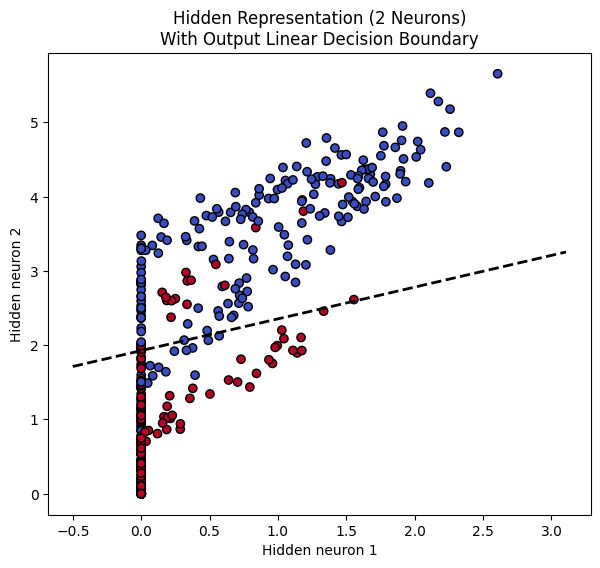

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# -----------------------
# 1️⃣ Data
# -----------------------
X, y = make_moons(n_samples=400, noise=0.2, random_state=0)
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.reshape(-1, 1)

# -----------------------
# 2️⃣ Activations
# -----------------------
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_hat):
    eps = 1e-8
    return -np.mean(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))

# -----------------------
# 3️⃣ Train Network (2 hidden neurons)
# -----------------------
def train_network(X, y, hidden_dim=2, epochs=5000, lr=0.1):

    n, d = X.shape

    W1 = np.random.randn(d, hidden_dim) * np.sqrt(2/d)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2/hidden_dim)
    b2 = np.zeros((1, 1))

    for _ in range(epochs):

        # Forward
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # Backward
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2 / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_deriv(Z1)
        dW1 = X.T @ dZ1 / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2

W1, b1, W2, b2 = train_network(X, y)

# -----------------------
# 4️⃣ Compute Hidden Representation
# -----------------------
Z1 = X @ W1 + b1
H = relu(Z1)

# -----------------------
# 5️⃣ Plot Hidden Space + Linear Boundary
# -----------------------
plt.figure(figsize=(7,6))

# Scatter hidden representations
plt.scatter(H[:, 0], H[:, 1], c=y.ravel(), cmap="coolwarm", edgecolor="k")

# Compute linear decision boundary in hidden space
# w1*h1 + w2*h2 + b = 0
w = W2.flatten()
b = b2.item()

h1_vals = np.linspace(H[:,0].min()-0.5, H[:,0].max()+0.5, 200)

if abs(w[1]) > 1e-6:
    h2_vals = -(w[0]*h1_vals + b) / w[1]
    plt.plot(h1_vals, h2_vals, 'k--', linewidth=2)

plt.xlabel("Hidden neuron 1")
plt.ylabel("Hidden neuron 2")
plt.title("Hidden Representation (2 Neurons)\nWith Output Linear Decision Boundary")
plt.show()


Exercise 3.15. Build and train a deeper network. Generate a more complex dataset: four interleaving spirals. Compare one-hidden-layer and two-hidden-layer networks. Experiment with depth to find what works best.

Training 1-hidden-layer network...
Training 2-hidden-layer network...


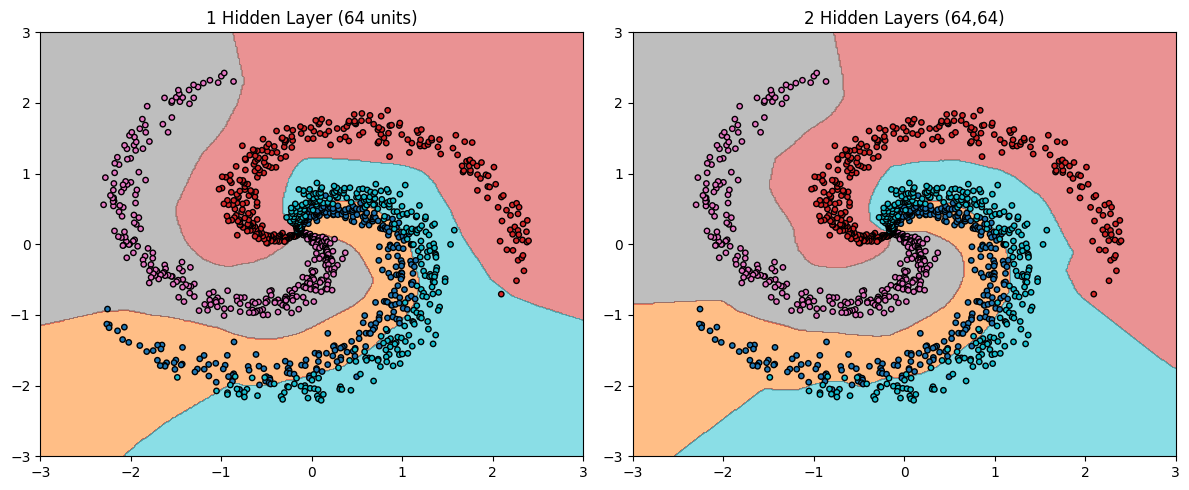

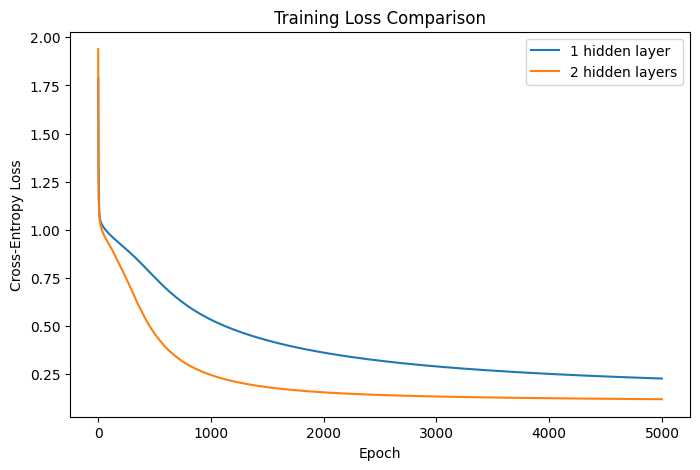

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# ============================================================
# 1️⃣ Generate Four Interleaving Spirals
# ============================================================
def generate_spirals(points_per_class=300, noise=0.2):
    K = 4  # classes
    N = points_per_class
    X = np.zeros((N*K, 2))
    y = np.zeros(N*K, dtype='uint8')

    for j in range(K):
        ix = range(N*j, N*(j+1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*noise
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j

    return X, y

X, y = generate_spirals()
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
num_classes = 4
Y = np.eye(num_classes)[y]

# ============================================================
# 2️⃣ Activations
# ============================================================
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    z -= np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

def compute_loss(Y, Y_hat):
    eps = 1e-8
    return -np.mean(np.sum(Y*np.log(Y_hat+eps), axis=1))

# ============================================================
# 3️⃣ Training Function (variable depth)
# ============================================================
def train_network(X, Y, hidden_dims, epochs=5000, lr=0.05):

    n, d = X.shape
    layer_dims = [d] + hidden_dims + [num_classes]

    # Initialize parameters
    params = {}
    for i in range(len(layer_dims)-1):
        params[f"W{i}"] = np.random.randn(layer_dims[i], layer_dims[i+1]) * np.sqrt(2/layer_dims[i])
        params[f"b{i}"] = np.zeros((1, layer_dims[i+1]))

    losses = []

    for _ in range(epochs):

        # Forward pass
        activations = [X]
        preacts = []

        A = X
        for i in range(len(hidden_dims)):
            Z = A @ params[f"W{i}"] + params[f"b{i}"]
            A = relu(Z)
            preacts.append(Z)
            activations.append(A)

        # Output layer
        Z_out = A @ params[f"W{len(hidden_dims)}"] + params[f"b{len(hidden_dims)}"]
        Y_hat = softmax(Z_out)

        loss = compute_loss(Y, Y_hat)
        losses.append(loss)

        # Backward pass
        dZ = (Y_hat - Y) / n

        # Output layer gradients
        params[f"W{len(hidden_dims)}"] -= lr * (activations[-1].T @ dZ)
        params[f"b{len(hidden_dims)}"] -= lr * np.sum(dZ, axis=0, keepdims=True)

        # Hidden layers (backprop)
        for i in reversed(range(len(hidden_dims))):
            dA = dZ @ params[f"W{i+1}"].T
            dZ = dA * relu_deriv(preacts[i])

            params[f"W{i}"] -= lr * (activations[i].T @ dZ)
            params[f"b{i}"] -= lr * np.sum(dZ, axis=0, keepdims=True)

    return params, losses

# ============================================================
# 4️⃣ Train Models
# ============================================================
print("Training 1-hidden-layer network...")
params_1, losses_1 = train_network(X, Y, hidden_dims=[64])

print("Training 2-hidden-layer network...")
params_2, losses_2 = train_network(X, Y, hidden_dims=[64, 64])

# ============================================================
# 5️⃣ Decision Boundary Function
# ============================================================
def plot_decision_boundary(params, hidden_dims, title):

    xx, yy = np.meshgrid(np.linspace(-3, 3, 400),
                         np.linspace(-3, 3, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    A = grid

    for i in range(len(hidden_dims)):
        Z = A @ params[f"W{i}"] + params[f"b{i}"]
        A = relu(Z)

    Z_out = A @ params[f"W{len(hidden_dims)}"] + params[f"b{len(hidden_dims)}"]
    probs = softmax(Z_out)
    preds = np.argmax(probs, axis=1)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=4, cmap="tab10", alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y, cmap="tab10", edgecolor="k", s=15)
    plt.title(title)

# ============================================================
# 6️⃣ Plot Results
# ============================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_decision_boundary(params_1, [64], "1 Hidden Layer (64 units)")

plt.subplot(1,2,2)
plot_decision_boundary(params_2, [64,64], "2 Hidden Layers (64,64)")

plt.tight_layout()
plt.show()

# Loss curves
plt.figure(figsize=(8,5))
plt.plot(losses_1, label="1 hidden layer")
plt.plot(losses_2, label="2 hidden layers")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()